# Q4

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## a)

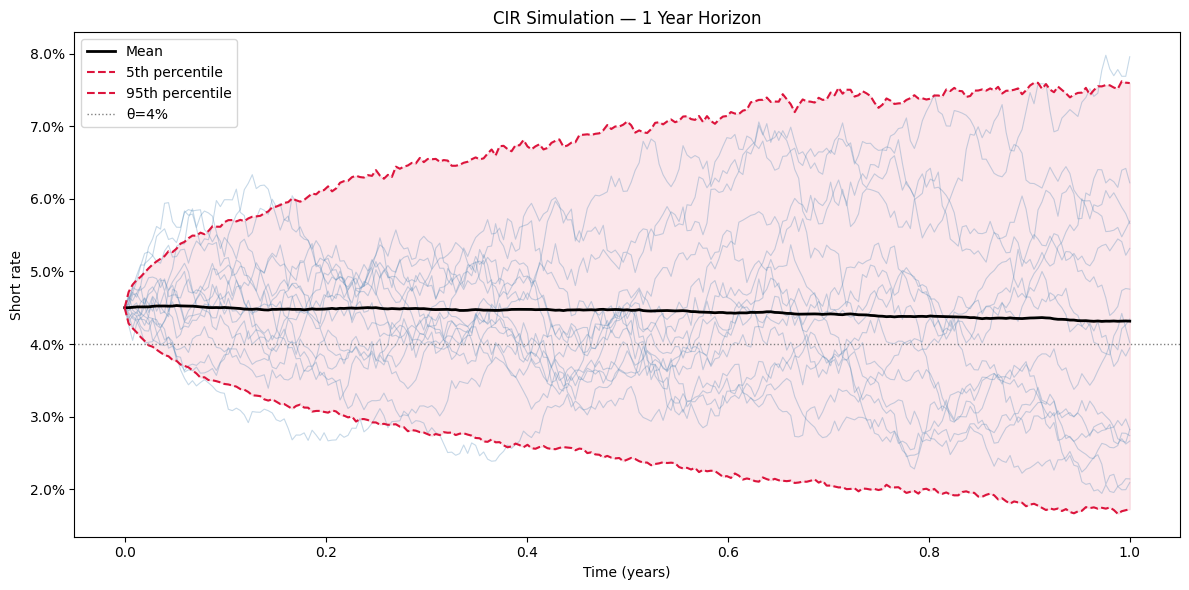

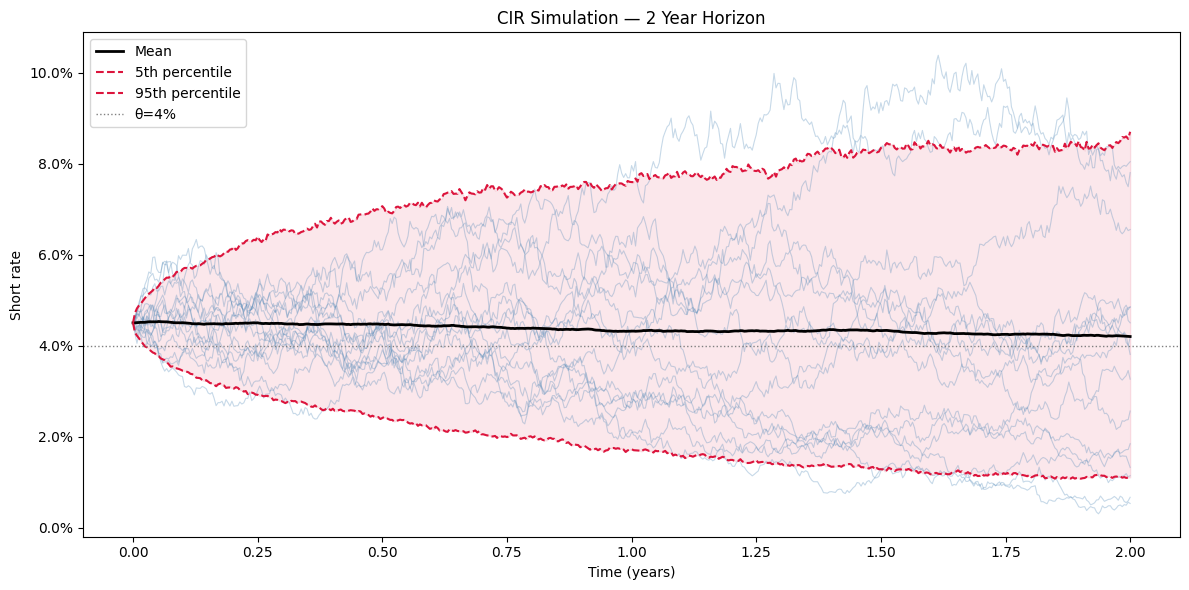

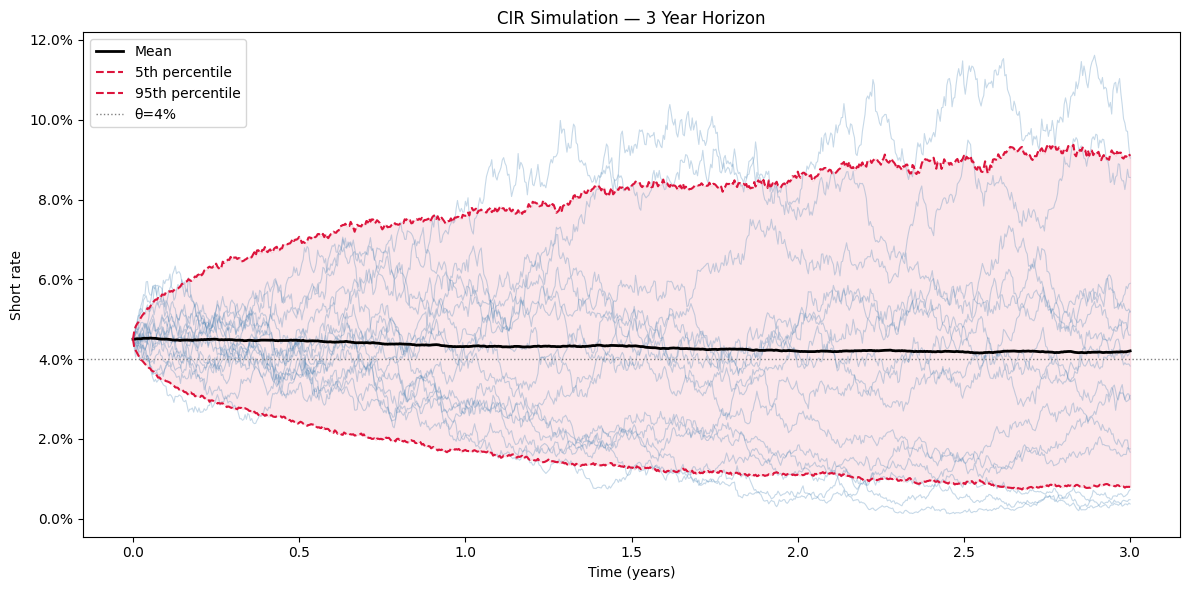

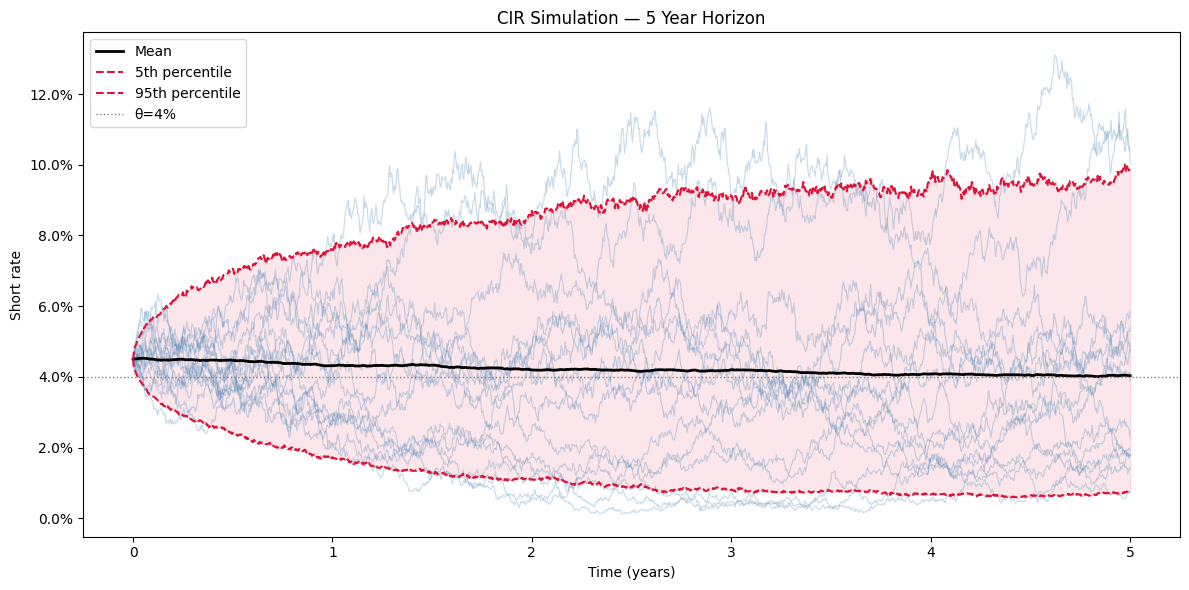

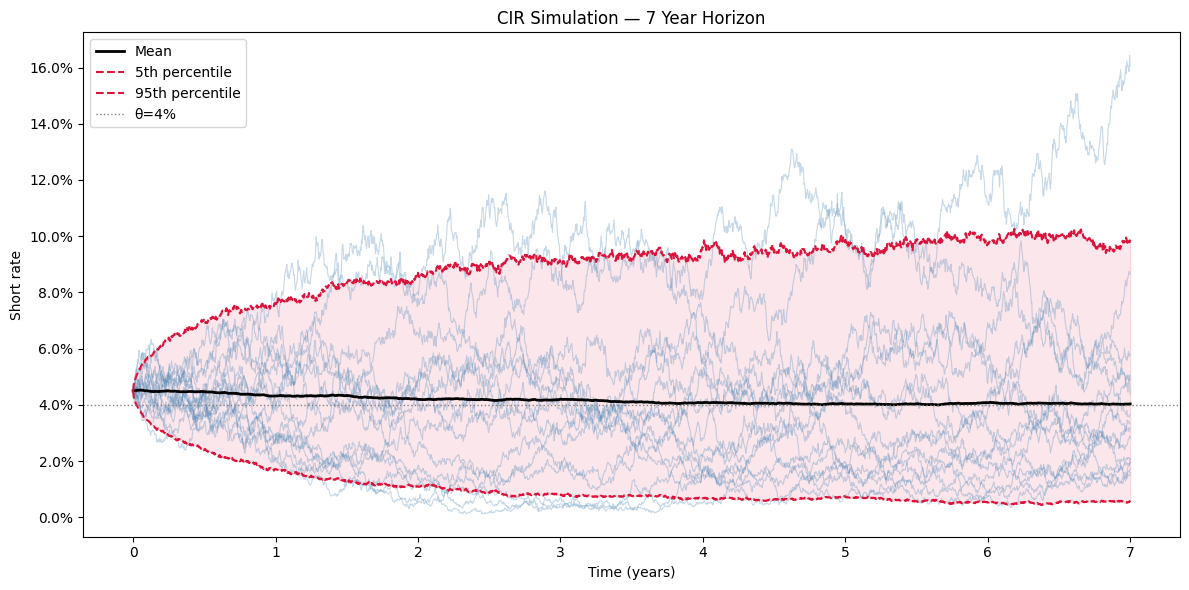

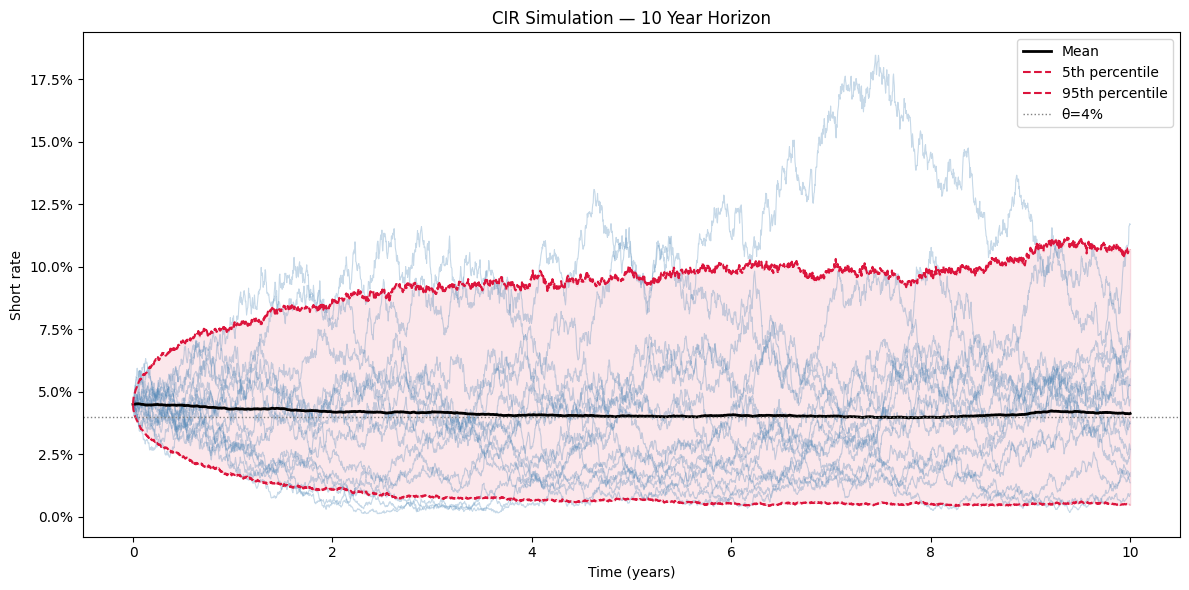

In [2]:
k = 0.2
theta = 0.04
sigma = 0.10
r0 = 0.045

n_paths = 1000
n_steps = 252

T = 10
dt = 1/n_steps

def simulate_cir_paths(k=0.2, theta=0.04, sigma=0.10, r0=0.045, T=10, n_paths=1000, n_steps=252):
    dt = 1/n_steps
    z = np.random.standard_normal((n_paths, T * n_steps))
    r = np.zeros((n_paths, T * n_steps + 1))
    r[:, 0] = r0

    for t in range(T * n_steps):
        r[:, t+1] = (r[:, t]
                     + k * (theta - r[:, t]) * dt
                     + sigma * np.sqrt(dt) * np.sqrt(np.maximum(r[:, t], 0)) * z[:, t])

    discount = np.exp(-np.cumsum(r, axis=1) * dt)
    return r, discount

r_paths, Pt = simulate_cir_paths(k, theta, sigma, r0, T=10, n_paths=1000, n_steps=252)
t_grid_full = np.linspace(0, 10, 10 * n_steps + 1)

for T in [1, 2, 3, 5, 7, 10]:
    n_steps_T = T * n_steps
    t_grid = t_grid_full[:n_steps_T + 1]
    r_T = r_paths[:, :n_steps_T + 1]

    sample_paths = r_T[:15, :]
    mean_path = r_T.mean(axis=0)
    p5  = np.percentile(r_T, 5,  axis=0)
    p95 = np.percentile(r_T, 95, axis=0)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(t_grid, sample_paths.T, color='steelblue', alpha=0.3, linewidth=0.8)
    ax.plot(t_grid, mean_path, color='black',  linewidth=2,   label='Mean')
    ax.plot(t_grid, p5,        color='crimson', linewidth=1.5, linestyle='--', label='5th percentile')
    ax.plot(t_grid, p95,       color='crimson', linewidth=1.5, linestyle='--', label='95th percentile')
    ax.fill_between(t_grid, p5, p95, color='crimson', alpha=0.1)
    ax.axhline(theta, color='gray', linewidth=1, linestyle=':', label=f'θ={theta:.0%}')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Short rate')
    ax.set_title(f'CIR Simulation — {T} Year Horizon')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

## b)

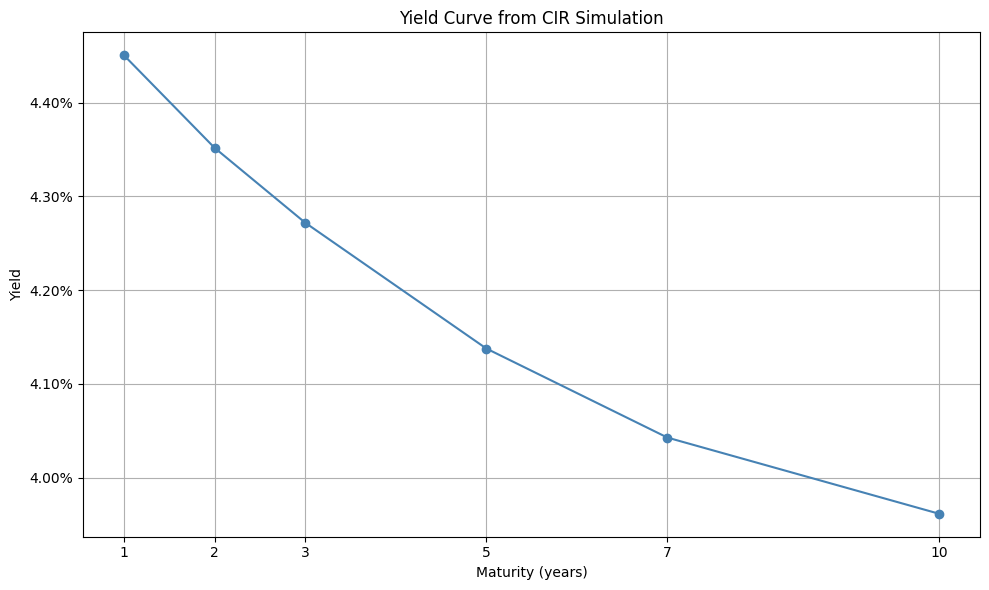

In [3]:
yt = []

for T in [1, 2, 3, 5, 7, 10]:
    n_steps_T = T * n_steps
    P_mean = Pt[:, n_steps_T].mean()
    yt.append(-np.log(P_mean) / T)

plt.figure(figsize=(10, 6))
plt.plot([1, 2, 3, 5, 7, 10], yt, marker='o', linestyle='-', color='steelblue')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield')
plt.title('Yield Curve from CIR Simulation')
plt.xticks([1, 2, 3, 5, 7, 10])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
plt.grid()
plt.tight_layout()
plt.show()



## c)

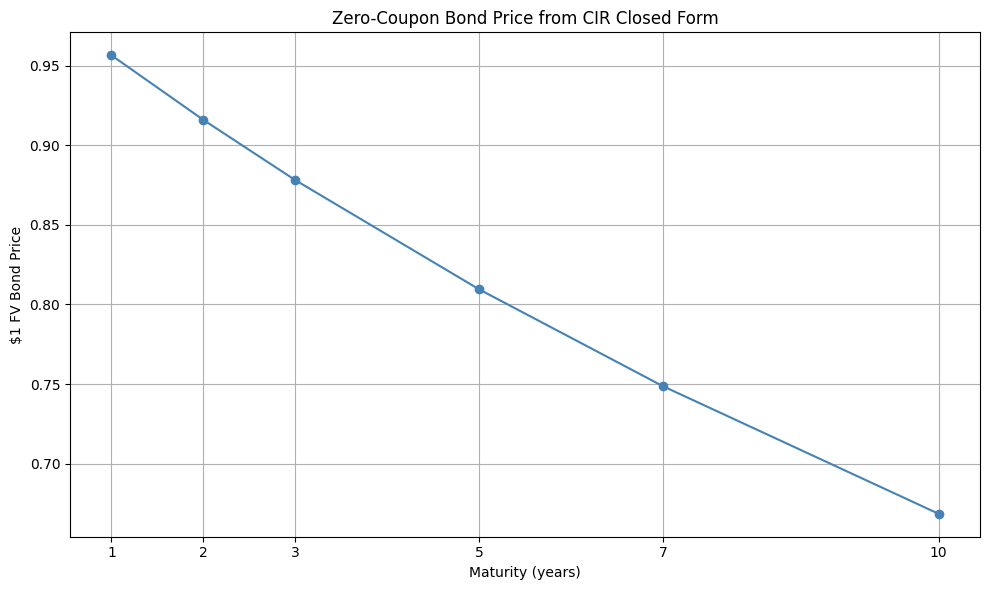

In [4]:
gamma = np.sqrt(k**2 + 2 * sigma**2)

def B(t):
    return (2 * (np.exp(gamma * t) - 1)) / ((gamma + k) * (np.exp(gamma * t) - 1) + 2 * gamma)

def A(t):
    return ((2 * gamma * np.exp((gamma + k) * t / 2)) / ((gamma + k) * (np.exp(gamma * t) - 1) + 2 * gamma))**(2 * k * theta / sigma**2)

def P_CIR(t, r=r0):
    return A(t) * np.exp(-B(t) * r)

pt = [P_CIR(T) for T in [1, 2, 3, 5, 7, 10]]

plt.figure(figsize=(10, 6))
plt.plot([1, 2, 3, 5, 7, 10], pt, marker='o', linestyle='-', color='steelblue')
plt.xlabel('Maturity (years)')
plt.ylabel('$1 FV Bond Price')
plt.title('Zero-Coupon Bond Price from CIR Closed Form')
plt.xticks([1, 2, 3, 5, 7, 10])
plt.grid()
plt.tight_layout()
plt.show()

## d)

In [5]:
dr = 0.001

def duration(r0, T, dr):
    P   = P_CIR(T, r0)
    P_u = P_CIR(T, r0 + dr)
    P_d = P_CIR(T, r0 - dr)
    return -(1/P) * (P_u - P_d) / (2 * dr)

def convexity(r0, T, dr):
    P   = P_CIR(T, r0)
    P_u = P_CIR(T, r0 + dr)
    P_d = P_CIR(T, r0 - dr)
    return (1/P) * (P_u - 2*P + P_d) / dr**2

D = duration(r0, 10, dr)
C = convexity(r0, 10, dr)

print(f"Duration:  {D:.4f} years")
print(f"Convexity: {C:.4f} years²")

Duration:  4.0713 years
Convexity: 16.5756 years²


# Q5

In [6]:
import numpy as np

# CIR Parameters (from Question 4)
kappa = 0.2
theta = 0.04
sigma = 0.10
r0 = 0.045


# CIR Closed-Form Zero-Coupon Bond Pricing (Approach 1: F=1)

def cir_discount(T, r, kappa=kappa, theta=theta, sigma=sigma):
    """
    Returns the CIR discount factor (price of a $1 zero-coupon bond)
    maturing at time T, given current short rate r.
    """
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)

    eGT = np.exp(gamma * T)

    B = (2 * (eGT - 1)) / ((gamma + kappa) * (eGT - 1) + 2 * gamma)

    A_base = (2 * gamma * np.exp((kappa + gamma) * T / 2)) / \
             ((gamma + kappa) * (eGT - 1) + 2 * gamma)
    A = A_base ** (2 * kappa * theta / sigma**2)

    return A * np.exp(-B * r)



# Coupon Bond Pricer

def price_coupon_bond(face, coupon_rate, maturity, r, freq=2):
    """
    Price a coupon bond under CIR.
    face:        face value (in $M)
    coupon_rate:  annual coupon rate (e.g. 0.025 for 2.5%)
    maturity:     years to maturity
    r:            current short rate
    freq:         coupon frequency per year (2 = semi-annual)
    """
    coupon = coupon_rate / freq * face  # dollar coupon per period
    n_payments = int(maturity * freq)

    total_price = 0.0
    for i in range(1, n_payments + 1):
        t_i = i / freq  # time of the i-th coupon
        df = cir_discount(t_i, r)
        total_price += coupon * df  # PV of coupon

    # Add PV of principal at maturity
    total_price += face * cir_discount(maturity, r)

    return total_price


# 5.1(a) - Price the Bank's Bond Portfolio

bond_A = price_coupon_bond(face=500, coupon_rate=0.025, maturity=5,  r=r0)
bond_B = price_coupon_bond(face=300, coupon_rate=0.020, maturity=10, r=r0)
bond_C = price_coupon_bond(face=200, coupon_rate=0.015, maturity=20, r=r0)

portfolio_value = bond_A + bond_B + bond_C


print("5.1(a) - Bond Pricing under CIR")
print("=" * 50)
print(f"Bond A (5yr,  2.5%): ${bond_A:,.4f}M")
print(f"Bond B (10yr, 2.0%): ${bond_B:,.4f}M")
print(f"Bond C (20yr, 1.5%): ${bond_C:,.4f}M")
print("=" * 50)
print(f"Total Portfolio V0:  ${portfolio_value:,.4f}M")


5.1(a) - Bond Pricing under CIR
Bond A (5yr,  2.5%): $460.3705M
Bond B (10yr, 2.0%): $249.1168M
Bond C (20yr, 1.5%): $133.8027M
Total Portfolio V0:  $843.2900M


In [7]:

# Duration & Convexity (reusable functions)

dr = 0.001  # 10 basis point bump

def bond_duration(face, coupon_rate, maturity, r, dr=dr):
    """Compute duration of a coupon bond via central finite difference."""
    P     = price_coupon_bond(face, coupon_rate, maturity, r)
    P_up  = price_coupon_bond(face, coupon_rate, maturity, r + dr)
    P_down = price_coupon_bond(face, coupon_rate, maturity, r - dr)

    duration = -(1 / P) * (P_up - P_down) / (2 * dr)
    return duration

def bond_convexity(face, coupon_rate, maturity, r, dr=dr):
    """Compute convexity of a coupon bond via central finite difference."""
    P     = price_coupon_bond(face, coupon_rate, maturity, r)
    P_up  = price_coupon_bond(face, coupon_rate, maturity, r + dr)
    P_down = price_coupon_bond(face, coupon_rate, maturity, r - dr)

    convexity = (1 / P) * (P_up - 2 * P + P_down) / (dr**2)
    return convexity



# 5.1(b) - Portfolio Duration

dur_A = bond_duration(face=500, coupon_rate=0.025, maturity=5,  r=r0)
dur_B = bond_duration(face=300, coupon_rate=0.020, maturity=10, r=r0)
dur_C = bond_duration(face=200, coupon_rate=0.015, maturity=20, r=r0)

# Weights = market value / total portfolio value
w_A = bond_A / portfolio_value
w_B = bond_B / portfolio_value
w_C = bond_C / portfolio_value

portfolio_duration = w_A * dur_A + w_B * dur_B + w_C * dur_C

# Interpretation: approximate loss from 100bp rate increase
delta_r = 0.01  # 100 basis points
approx_loss = -portfolio_duration * delta_r * portfolio_value



print("5.1(b) - Duration")
print("=" * 50)
print(f"Bond A duration: {dur_A:.4f}")
print(f"Bond B duration: {dur_B:.4f}")
print(f"Bond C duration: {dur_C:.4f}")
print()
print(f"Weights:  A={w_A:.4f}  B={w_B:.4f}  C={w_C:.4f}")
print(f"Portfolio duration: {portfolio_duration:.4f}")
print()
print(f"If rates rise 100bp, approximate loss:")
print(f"  ΔV ≈ -{portfolio_duration:.4f} × 0.01 × {portfolio_value:,.2f}")
print(f"  ΔV ≈ ${approx_loss:,.4f}M")

5.1(b) - Duration
Bond A duration: 2.9418
Bond B duration: 3.8084
Bond C duration: 4.1279

Weights:  A=0.5459  B=0.2954  C=0.1587
Portfolio duration: 3.3860

If rates rise 100bp, approximate loss:
  ΔV ≈ -3.3860 × 0.01 × 843.29
  ΔV ≈ $-28.5537M


In [8]:

# 5.2(a) - Deterministic Stress Test (200bp shock)

r_shocked = 0.065  # r0 + 200bp

# Reprice each bond at the shocked rate
bond_A_shocked = price_coupon_bond(face=500, coupon_rate=0.025, maturity=5,  r=r_shocked)
bond_B_shocked = price_coupon_bond(face=300, coupon_rate=0.020, maturity=10, r=r_shocked)
bond_C_shocked = price_coupon_bond(face=200, coupon_rate=0.015, maturity=20, r=r_shocked)

portfolio_shocked = bond_A_shocked + bond_B_shocked + bond_C_shocked

# Actual loss
actual_loss = portfolio_shocked - portfolio_value
pct_loss = actual_loss / portfolio_value * 100

# Duration-only approximation
shock = 0.02  # 200bp
duration_approx = -portfolio_duration * shock * portfolio_value

# Convexity
conv_A = bond_convexity(face=500, coupon_rate=0.025, maturity=5,  r=r0)
conv_B = bond_convexity(face=300, coupon_rate=0.020, maturity=10, r=r0)
conv_C = bond_convexity(face=200, coupon_rate=0.015, maturity=20, r=r0)

portfolio_convexity = w_A * conv_A + w_B * conv_B + w_C * conv_C

# Duration + convexity approximation
dur_conv_approx = (-portfolio_duration * shock + 0.5 * portfolio_convexity * shock**2) * portfolio_value

# Gap analysis
gap = actual_loss - duration_approx
convexity_correction = 0.5 * portfolio_convexity * shock**2 * portfolio_value



print("5.2(a) - Deterministic Stress Test (+200bp)")
print("=" * 50)
print(f"Shocked rate: {r_shocked*100:.1f}%")
print()
print(f"Bond A shocked: ${bond_A_shocked:,.4f}M  (was ${bond_A:,.4f}M)")
print(f"Bond B shocked: ${bond_B_shocked:,.4f}M  (was ${bond_B:,.4f}M)")
print(f"Bond C shocked: ${bond_C_shocked:,.4f}M  (was ${bond_C:,.4f}M)")
print()
print(f"Portfolio shocked:  ${portfolio_shocked:,.4f}M")
print(f"Portfolio original: ${portfolio_value:,.4f}M")
print(f"Actual loss:        ${actual_loss:,.4f}M  ({pct_loss:.2f}%)")
print()
print(f"Duration-only approx:     ${duration_approx:,.4f}M")
print(f"Duration+convexity approx: ${dur_conv_approx:,.4f}M")
print(f"Actual loss:               ${actual_loss:,.4f}M")
print()
print(f"Gap (actual vs duration-only): ${gap:,.4f}M")
print(f"Convexity correction:          ${convexity_correction:,.4f}M")
print(f"Remaining error:               ${actual_loss - dur_conv_approx:,.4f}M")

5.2(a) - Deterministic Stress Test (+200bp)
Shocked rate: 6.5%

Bond A shocked: $434.0857M  (was $460.3705M)
Bond B shocked: $230.8712M  (was $249.1168M)
Bond C shocked: $123.2166M  (was $133.8027M)

Portfolio shocked:  $788.1735M
Portfolio original: $843.2900M
Actual loss:        $-55.1165M  (-6.54%)

Duration-only approx:     $-57.1074M
Duration+convexity approx: $-55.0673M
Actual loss:               $-55.1165M

Gap (actual vs duration-only): $1.9909M
Convexity correction:          $2.0402M
Remaining error:               $-0.0492M


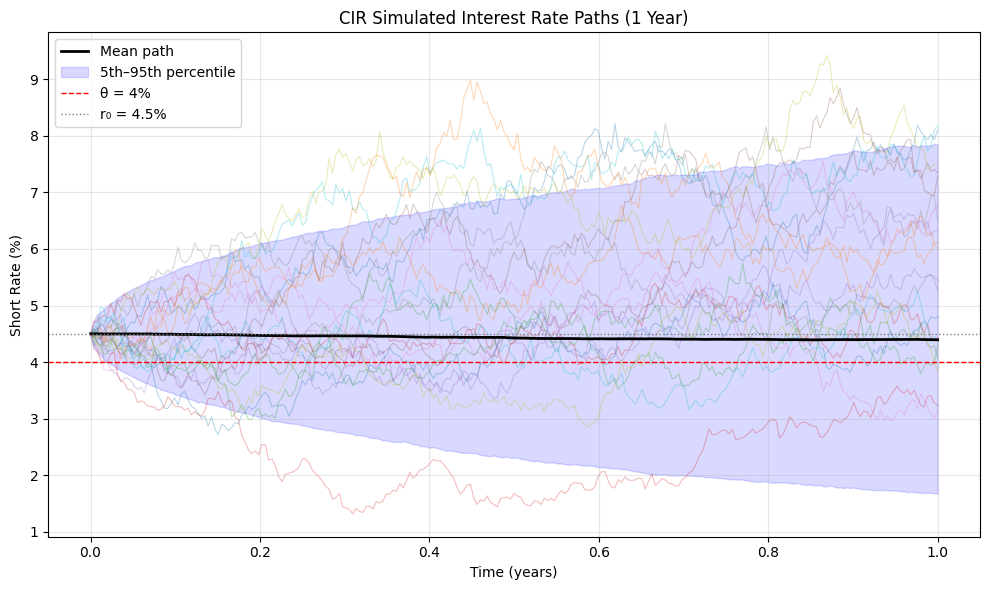

In [9]:

# 5.2(b) - Monte Carlo Stress Test: Simulate CIR Paths

np.random.seed(42)

N_paths = 10_000
n_steps = 252       # daily steps for 1 year
dt = 1 / 252

# Array to store all paths: shape (N_paths, n_steps+1)
# Each row is one path, columns are daily rate values
rates = np.zeros((N_paths, n_steps + 1))
rates[:, 0] = r0  # all paths start at r0

for t in range(n_steps):
    Z = np.random.standard_normal(N_paths)
    r_t = rates[:, t]
    dr = kappa * (theta - r_t) * dt + sigma * np.sqrt(r_t) * np.sqrt(dt) * Z
    rates[:, t + 1] = np.maximum(r_t + dr, 0)  # floor at zero

# Terminal rates after 1 year
r1 = rates[:, -1]

# Plot sample paths
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

time_axis = np.linspace(0, 1, n_steps + 1)  # 0 to 1 year

# Plot 20 sample paths
for i in range(20):
    ax.plot(time_axis, rates[i, :] * 100, alpha=0.3, linewidth=0.8)

# Mean path
mean_path = np.mean(rates, axis=0)
ax.plot(time_axis, mean_path * 100, color='black', linewidth=2, label='Mean path')

# 5th and 95th percentile bands
p5 = np.percentile(rates, 5, axis=0)
p95 = np.percentile(rates, 95, axis=0)
ax.fill_between(time_axis, p5 * 100, p95 * 100, alpha=0.15, color='blue', label='5th–95th percentile')

# Reference lines
ax.axhline(y=theta * 100, color='red', linestyle='--', linewidth=1, label=f'θ = {theta*100:.0f}%')
ax.axhline(y=r0 * 100, color='gray', linestyle=':', linewidth=1, label=f'r₀ = {r0*100:.1f}%')

ax.set_xlabel('Time (years)')
ax.set_ylabel('Short Rate (%)')
ax.set_title('CIR Simulated Interest Rate Paths (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("cir_paths.png", dpi=300, bbox_inches='tight')
plt.tight_layout()

In [10]:

# 5.2(c) - Reprice Portfolio at Each Simulated r1, Compute P&L


# Coupons received during the year (fixed, same for all scenarios)
coupons_A = 2 * (0.025 / 2) * 500   # 2 semi-annual payments = $12.5M
coupons_B = 2 * (0.020 / 2) * 300   # = $6.0M
coupons_C = 2 * (0.015 / 2) * 200   # = $3.0M
total_coupons = coupons_A + coupons_B + coupons_C

# Reprice each bond at each r1 with reduced maturities
PnL = np.zeros(N_paths)

for i in range(N_paths):
    r_end = r1[i]

    # Bonds are now 1 year shorter
    V1_A = price_coupon_bond(face=500, coupon_rate=0.025, maturity=4,  r=r_end)
    V1_B = price_coupon_bond(face=300, coupon_rate=0.020, maturity=9,  r=r_end)
    V1_C = price_coupon_bond(face=200, coupon_rate=0.015, maturity=19, r=r_end)

    V1 = V1_A + V1_B + V1_C
    PnL[i] = V1 + total_coupons - portfolio_value

print("1 year Average Pnl of the 10,000 runs : ",np.mean(PnL))


1 year Average Pnl of the 10,000 runs :  37.971910466699114


5.2(d) - P&L Distribution & Value-at-Risk
Mean P&L:              $37.97M
5th percentile (VaR95): $-52.49M
1st percentile (VaR99): $-94.83M


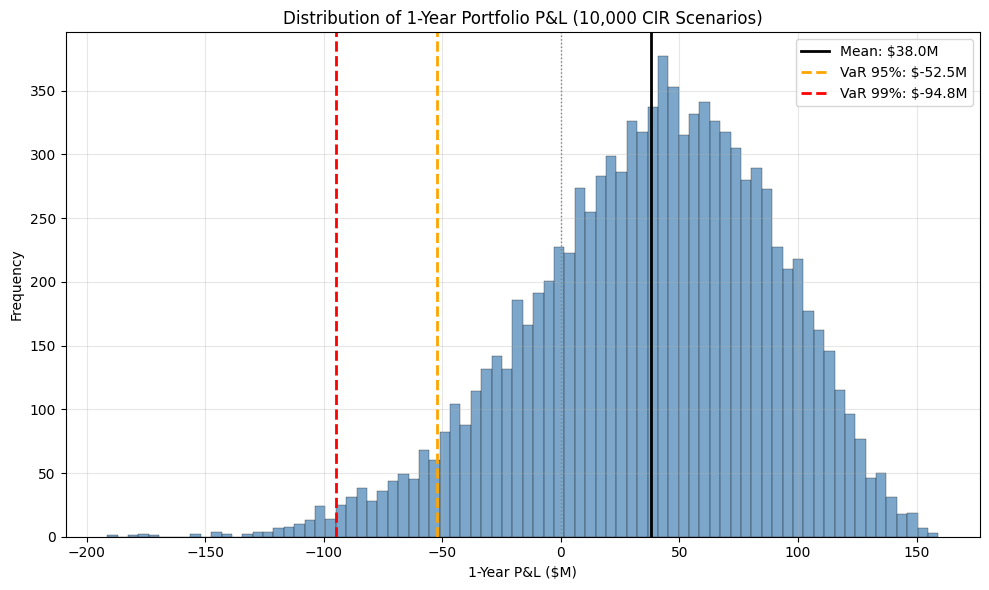

In [11]:

# 5.2(d) - P&L Distribution and Value-at-Risk

mean_pnl = np.mean(PnL)
p5_pnl = np.percentile(PnL, 5)    # 95% VaR
p1_pnl = np.percentile(PnL, 1)    # 99% VaR



print("5.2(d) - P&L Distribution & Value-at-Risk")
print("=" * 50)
print(f"Mean P&L:              ${mean_pnl:,.2f}M")
print(f"5th percentile (VaR95): ${p5_pnl:,.2f}M")
print(f"1st percentile (VaR99): ${p1_pnl:,.2f}M")

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(PnL, bins=80, edgecolor='black', linewidth=0.3, alpha=0.7, color='steelblue')

# Vertical lines for mean and VaR
ax.axvline(mean_pnl, color='black', linewidth=2, label=f'Mean: ${mean_pnl:,.1f}M')
ax.axvline(p5_pnl, color='orange', linewidth=2, linestyle='--', label=f'VaR 95%: ${p5_pnl:,.1f}M')
ax.axvline(p1_pnl, color='red', linewidth=2, linestyle='--', label=f'VaR 99%: ${p1_pnl:,.1f}M')
ax.axvline(0, color='gray', linewidth=1, linestyle=':')

ax.set_xlabel('1-Year P&L ($M)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of 1-Year Portfolio P&L (10,000 CIR Scenarios)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("pnl_distribution.png", dpi=300, bbox_inches='tight')
plt.tight_layout()

In [14]:
# 5.3(a) - Price Interest Rate Cap via Monte Carlo

N_cap = 50_000         # more paths for smoother cap pricing
n_steps_5yr = 252 * 5  # daily steps for 5 years
dt_cap = 1 / 252
notional = 1000        # $1,000M
delta = 0.5            # semi-annual accrual
caplet_times = np.arange(0.5, 5.5, 0.5)  # t = 0.5, 1.0, ..., 5.0
caplet_steps = (caplet_times * 252).astype(int)  # which daily step each caplet falls on

# Make sure kappa is the CIR speed-of-reversion (don't let prior loop vars clobber it)
kappa = 0.2

strikes = np.arange(0.05, 0.0825, 0.0025)  # 5.00% to 8.00% in 25bp

def simulate_cir_paths_cap(r_start, n_paths, n_steps, dt, seed=123):
    """Simulate CIR paths, return full rate array."""
    np.random.seed(seed)
    r = np.zeros((n_paths, n_steps + 1))
    r[:, 0] = r_start
    for t in range(n_steps):
        Z = np.random.standard_normal(n_paths)
        r_t = r[:, t]
        dr_step = kappa * (theta - r_t) * dt + sigma * np.sqrt(r_t) * np.sqrt(dt) * Z
        r[:, t + 1] = np.maximum(r_t + dr_step, 0)
    return r

def price_cap(r_paths, strike, dt):
    """
    Price an interest rate cap given simulated paths.
    Returns the cap price (in $M).
    """
    n_paths = r_paths.shape[0]
    cap_values = np.zeros(n_paths)

    for idx, step in enumerate(caplet_steps):
        r_at_caplet = r_paths[:, step]
        payoff = delta * notional * np.maximum(r_at_caplet - strike, 0)
        cum_rate = np.sum(r_paths[:, :step], axis=1) * dt
        discount = np.exp(-cum_rate)
        cap_values += payoff * discount

    return np.mean(cap_values)

# Simulate paths starting at r0
paths_r0 = simulate_cir_paths_cap(r0, N_cap, n_steps_5yr, dt_cap, seed=123)

# Price cap at each strike under original rate
cap_prices_r0 = np.array([price_cap(paths_r0, strike_i, dt_cap) for strike_i in strikes])

print('5.3(a) - Cap prices at r0 = 4.5% (selected strikes):')
print('=' * 50)
for strike_i, price_i in zip(strikes, cap_prices_r0):
    # Print a subset for the report (every 25bp)
    if np.isclose((strike_i * 10000) % 25, 0):
        print(f'  Strike {strike_i*100:4.2f}%: ${price_i:6.2f}M')


5.3(a) - Cap prices at r0 = 4.5% (selected strikes):
  Strike 5.00%: $ 29.58M
  Strike 5.25%: $ 26.22M
  Strike 5.50%: $ 23.22M
  Strike 5.75%: $ 20.55M
  Strike 6.00%: $ 18.17M
  Strike 6.25%: $ 16.06M
  Strike 6.50%: $ 14.19M
  Strike 6.75%: $ 12.53M
  Strike 7.00%: $ 11.07M
  Strike 7.25%: $  9.77M
  Strike 7.50%: $  8.63M
  Strike 7.75%: $  7.63M
  Strike 8.00%: $  6.73M


5.3(b) - Net Hedged P&L under 200bp Shock
Unhedged loss:     $-55.12M
Best strike:       7.00%
Net P&L at best:   $-52.75M
Improvement:       $2.36M (4.3%)

  Strike     Cap(r0)    Cap(shocked)    Cap gain     Net P&L
   5.00%       29.58           57.23       27.65      -57.04
   5.25%       26.22           51.87       25.65      -55.69
   5.50%       23.22           46.90       23.68      -54.67
   5.75%       20.55           42.30       21.75      -53.92
   6.00%       18.17           38.06       19.89      -53.39
   6.25%       16.06           34.18       18.12      -53.05
   6.50%       14.19           30.64       16.45      -52.85
   6.75%       12.53           27.42       14.89      -52.76
   7.00%       11.07           24.50       13.43      -52.75  <-- best
   7.25%        9.77           21.87       12.09      -52.80
   7.50%        8.63           19.49       10.86      -52.89
   7.75%        7.63           17.36        9.73      -53.01
   8.00%        6.73           15.45    

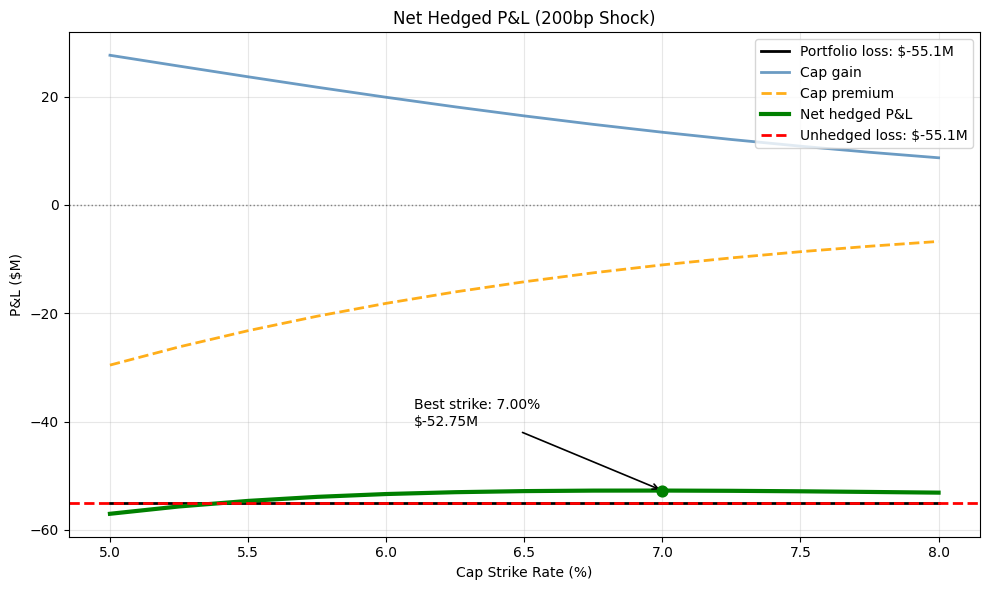

In [13]:
# 5.3(b) - Hedge Evaluation Under 200bp Shock

r_shocked = 0.065  # r0 + 200bp

# Use the SAME seed as paths_r0 (common random numbers) so that cap_gain
# reflects only the change in starting rate, not Monte Carlo noise.
paths_shocked = simulate_cir_paths_cap(r_shocked, N_cap, n_steps_5yr, dt_cap, seed=123)

# Price cap at each strike under shocked rate
cap_prices_shocked = np.array([price_cap(paths_shocked, strike_i, dt_cap) for strike_i in strikes])

# Components of the hedge
cap_gain = cap_prices_shocked - cap_prices_r0       # in-place gain on an existing cap
premium_cost = cap_prices_r0                        # upfront premium already paid
net_pnl = actual_loss + cap_gain - premium_cost     # portfolio loss is negative (-55.12)

# Find the best strike
best_idx = np.argmax(net_pnl)
best_strike = strikes[best_idx]
best_netpnl = net_pnl[best_idx]
improvement = best_netpnl - actual_loss  # positive => hedge helps

print('5.3(b) - Net Hedged P&L under 200bp Shock')
print('=' * 60)
print(f'Unhedged loss:     ${actual_loss:,.2f}M')
print(f'Best strike:       {best_strike*100:.2f}%')
print(f'Net P&L at best:   ${best_netpnl:,.2f}M')
print(f'Improvement:       ${improvement:,.2f}M ({improvement/abs(actual_loss)*100:.1f}%)')
print()
print(f'{"Strike":>8}  {"Cap(r0)":>10}  {"Cap(shocked)":>14}  {"Cap gain":>10}  {"Net P&L":>10}')
for i, s in enumerate(strikes):
    marker = '  <-- best' if i == best_idx else ''
    print(f'{s*100:>7.2f}%  {cap_prices_r0[i]:>10.2f}  {cap_prices_shocked[i]:>14.2f}  '
          f'{cap_gain[i]:>10.2f}  {net_pnl[i]:>10.2f}{marker}')

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

s = strikes * 100
portfolio_loss_line = np.full_like(strikes, actual_loss)
premium_line = -premium_cost  # plotted as a negative number (cost)

ax.plot(s, portfolio_loss_line, color='black', linewidth=2,
        label=f'Portfolio loss: ${actual_loss:,.1f}M')
ax.plot(s, cap_gain, color='steelblue', linewidth=2, alpha=0.8, label='Cap gain')
ax.plot(s, premium_line, color='orange', linewidth=2, linestyle='--',
        alpha=0.9, label='Cap premium')
ax.plot(s, net_pnl, color='green', linewidth=3, label='Net hedged P&L')

# Reference lines
ax.axhline(0, color='gray', linewidth=1, linestyle=':')
ax.axhline(actual_loss, color='red', linestyle='--', linewidth=2,
           label=f'Unhedged loss: ${actual_loss:,.1f}M')

# Best-strike marker (uses the ACTUAL argmax, not a hardcoded number)
ax.scatter(s[best_idx], net_pnl[best_idx], color='green', s=60, zorder=5)
ax.annotate(
    f'Best strike: {best_strike*100:.2f}%\n${best_netpnl:,.2f}M',
    xy=(s[best_idx], net_pnl[best_idx]),
    xytext=(s[best_idx] - 0.9, net_pnl[best_idx] + 12),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
)

ax.set_xlabel('Cap Strike Rate (%)')
ax.set_ylabel('P&L ($M)')
ax.set_title('Net Hedged P&L (200bp Shock)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hedged_pnl.png', dpi=300, bbox_inches='tight')
plt.show()
